In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/models/lamthicucb2203709/teacher-sum/keras/default/1/teacher_ssl_dnn.pth
/kaggle/input/models/lamthicucb2203709/teacher-sum/keras/default/1/xgboost_best_model.json
/kaggle/input/models/lamthicucb2203709/teacher-sum/keras/default/1/dnn-teacher.keras
/kaggle/input/models/lamthicucb2203709/teacher-sum/keras/default/1/lstm-teacher.keras
/kaggle/input/models/lamthicucb2203709/teacher-sum/keras/default/1/best_model_cnn1d_128_128_256.keras
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/train_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/full_dataset_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_minmax_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/class_weights_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/feature_columns_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet
/ka

In [2]:
 # !mkdir /kaggle/working/training_checkpoints
 # !cp /kaggle/input/datasets/binhthanh69/lstm-7t/training_checkpoints/* /kaggle/working/training_checkpoints/


In [3]:
import os
import json
import pandas as pd

OUTPUT_DIR = "/kaggle/working/"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
metadata_path = f"{OUTPUT_DIR}/metadata.json"

def create_metadata_from_parquet(train_path):
    df = pd.read_parquet(train_path)
    all_columns = df.columns.tolist()
    target_col = 'label'
    if target_col not in all_columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    feature_cols = [col for col in all_columns if col != target_col]
    num_features = len(feature_cols)
    unique_labels = sorted(df[target_col].astype(str).unique())
    num_classes = len(unique_labels)
    label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
    id_to_label = {str(idx): label for idx, label in enumerate(unique_labels)}
    metadata = {
        "feature_cols": feature_cols,
        "target_col": target_col,
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "num_classes": num_classes,
        "num_features": num_features
    }
    return metadata

if not os.path.exists(metadata_path):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    metadata = create_metadata_from_parquet(TRAIN_PATH)
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")
else:
    print("Metadata already exists.")

Metadata saved to /kaggle/working//metadata.json


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 1: Imports & Config
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import xgboost as xgb

# Hyperparameters
BATCH_SIZE = 128
LEARNING_RATE = 0.005
EPOCHS = 50
TEMPERATURE = 2.0
ALPHA = 0.1

# Paths (adjust to your environment)
OUTPUT_DIR = "/kaggle/working/"
METADATA_PATH = f"{OUTPUT_DIR}/metadata.json"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"
TEST_PATH  = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
XGB_MODEL_PATH = "/kaggle/input/models/lamthicucb2203709/teacher-sum/keras/default/1/xgboost_best_model.json"
LSTM_MODEL_PATH = "/kaggle/input/models/lamthicucb2203709/teacher-sum/keras/default/1/lstm-teacher.keras"

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 2: Load Data
# ──────────────────────────────────────────────────────────────────────────────
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
target_col = metadata['target_col']
num_classes = metadata['num_classes']
num_features = metadata['num_features']

df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
df_test  = pd.read_parquet(TEST_PATH)

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[target_col].values.astype(np.int32)
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val[target_col].values.astype(np.int32)
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test[target_col].values.astype(np.int32)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Number of classes: {num_classes}")
# Tính class weights dựa trên y_train (đã undersampled)
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(y_train)
class_weights_raw = compute_class_weight('balanced', classes=unique_classes, y=y_train)
# Giới hạn weight tối đa = 3.0
MAX_WEIGHT = 3.0
class_weights = np.minimum(class_weights_raw, MAX_WEIGHT)

print("Class counts:", np.bincount(y_train))
print("Class weights (capped at 3.0):", class_weights)

# Chuyển thành tensor để dùng trong loss
class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)

Train: (4468344, 37), Val: (1117087, 37), Test: (1396358, 37)
Number of classes: 8
Class counts: [ 670231 1916729  619802    8013  278953  383443   15173  576000]
Class weights (capped at 3.0): [0.83335895 0.29140426 0.9011636  3.         2.00228354 1.45665197
 3.         0.96969271]


I0000 00:00:1786352665.929455      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786352665.932187      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 3: Load Teacher Models
# ──────────────────────────────────────────────────────────────────────────────
# XGBoost (outputs probabilities)
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(XGB_MODEL_PATH)

# CNN (outputs logits)
cnn_model = tf.keras.models.load_model(LSTM_MODEL_PATH)

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 4: Build Student Model (MLP 64-32, outputs logits)
# ──────────────────────────────────────────────────────────────────────────────
def build_student(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='linear')   # logits
    ])
    return model

student = build_student(num_features, num_classes)
student.summary()
print(f"Student parameters: {student.count_params()}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,776 (18.66 KB)

 Trainable params: 4,776 (18.66 KB)

 Non-trainable params: 0 (0.00 B)

Student parameters: 4776


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 5: Precompute XGBoost probabilities & Create tf.data.Datasets
# ──────────────────────────────────────────────────────────────────────────────
print("Precomputing XGBoost probabilities...")
xgb_probs_train = xgb_model.predict_proba(X_train).astype(np.float32)
xgb_probs_val   = xgb_model.predict_proba(X_val).astype(np.float32)
xgb_probs_test  = xgb_model.predict_proba(X_test).astype(np.float32)

print(f"Train shape: {xgb_probs_train.shape}, Val shape: {xgb_probs_val.shape}")

# Tạo dataset kèm theo probs đã precompute
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, xgb_probs_train)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val, y_val, xgb_probs_val)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test, xgb_probs_test)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Precomputing XGBoost probabilities...
Train shape: (4468344, 8), Val shape: (1117087, 8)


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 6: Loss Function and Training Step (with class weights)
# ──────────────────────────────────────────────────────────────────────────────
ce_loss = losses.SparseCategoricalCrossentropy(from_logits=True)

@tf.function
def distillation_loss(student_logits, fused_teacher_probs, true_labels, alpha, temperature, class_weights):
    # Hard loss with class weights
    hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=true_labels, logits=student_logits
    )
    weights = tf.gather(class_weights, true_labels)
    hard_loss = tf.reduce_mean(hard_loss_per_sample * weights)
    
    # KD loss
    student_probs = tf.nn.softmax(student_logits / temperature)
    kd_loss = tf.reduce_mean(
        tf.reduce_sum(fused_teacher_probs * tf.math.log(fused_teacher_probs / (student_probs + 1e-8)), axis=1)
    ) * (temperature ** 2)
    
    return (1 - alpha) * hard_loss + alpha * kd_loss

def train_step(x_batch, y_batch, xgb_probs_batch):
    # CNN teacher: logits -> softmax with temperature
    cnn_logits = cnn_model(x_batch, training=False)
    cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)
    
    # XGBoost: precomputed probabilities -> temperature scaling
    xgb_probs_tf = tf.constant(xgb_probs_batch, dtype=tf.float32)
    xgb_probs_scaled = xgb_probs_tf ** (1.0 / TEMPERATURE)
    xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)
    
    teacher_probs = [cnn_probs, xgb_probs_scaled]
    
    # Compute confidence weights per batch (batch‑wise mean of max prob)
    conf_scores = []
    for probs in teacher_probs:
        max_probs = tf.reduce_max(probs, axis=1)
        conf = tf.reduce_mean(max_probs)
        conf_scores.append(conf)
    conf_scores = tf.stack(conf_scores)
    weights = conf_scores / tf.reduce_sum(conf_scores)
    
    # Fuse teacher predictions (same weights for whole batch)
    fused = weights[0] * teacher_probs[0] + weights[1] * teacher_probs[1]
    
    # Student forward and loss
    with tf.GradientTape() as tape:
        student_logits = student(x_batch, training=True)
        loss = distillation_loss(student_logits, fused, y_batch, ALPHA, TEMPERATURE, class_weights_tensor)
    grads = tape.gradient(loss, student.trainable_variables)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss

In [10]:
import pickle
import glob
import json
import tensorflow as tf

CHECKPOINT_DIR = f"{OUTPUT_DIR}/training_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# File lưu metadata
METADATA_FILE = f"{CHECKPOINT_DIR}/metadata.pkl"

def save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights):
    metadata = {
        'epoch': epoch,
        'best_val_loss': best_val_loss,
        'wait_lr': wait_lr,
        'current_lr': current_lr,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_weights': best_weights
    }
    with open(METADATA_FILE, 'wb') as f:
        pickle.dump(metadata, f)

def load_metadata():
    if not os.path.exists(METADATA_FILE):
        return None, 0
    with open(METADATA_FILE, 'rb') as f:
        metadata = pickle.load(f)
    return metadata, metadata['epoch']

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 7: Training Loop với cải tiến (bỏ ES, checkpoint resume với optimizer state)
# ──────────────────────────────────────────────────────────────────────────────
from tqdm.auto import tqdm
import tensorflow as tf

GRAD_CLIP_NORM = 1.0

# Khởi tạo optimizer (Adam)
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)

# Tạo checkpoint object (lưu model + optimizer)
checkpoint = tf.train.Checkpoint(model=student, optimizer=optimizer)
checkpoint_manager = tf.train.CheckpointManager(
    checkpoint, 
    directory=CHECKPOINT_DIR,
    max_to_keep=2
)

# Load metadata và checkpoint nếu có
metadata, start_epoch = load_metadata()
if metadata is not None:
    print(f"Resuming from epoch {start_epoch}")
    best_val_loss = metadata['best_val_loss']
    wait_lr = metadata['wait_lr']
    current_lr = metadata['current_lr']
    train_losses = metadata['train_losses']
    val_losses = metadata['val_losses']
    train_accuracies = metadata['train_accuracies']
    val_accuracies = metadata['val_accuracies']
    best_weights = metadata['best_weights']
    # Khôi phục optimizer và model weights từ checkpoint
    latest_checkpoint = tf.train.latest_checkpoint(CHECKPOINT_DIR)
    if latest_checkpoint is not None:
        checkpoint.restore(latest_checkpoint).expect_partial()
        print(f"  ✅ Restored model and optimizer from {latest_checkpoint}")
    else:
        print("  ⚠️  No checkpoint file found, but metadata exists. Starting fresh.")
    epoch_start = start_epoch + 1
else:
    print("Starting fresh training")
    best_val_loss = float('inf')
    best_weights = None
    wait_lr = 0
    current_lr = LEARNING_RATE
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    epoch_start = 1

# Các tham số ReduceLROnPlateau
patience_lr = 5
lr_factor = 0.5
min_lr = 1e-4

# Hàm train_step với gradient clipping
@tf.function
def train_step(x_batch, y_batch, xgb_probs_batch):
    # Teacher CNN
    cnn_logits = cnn_model(x_batch, training=False)
    cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)
    
    # Teacher XGBoost
    xgb_probs_scaled = xgb_probs_batch ** (1.0 / TEMPERATURE)
    xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)
    
    teacher_probs = [cnn_probs, xgb_probs_scaled]
    
    # Confidence weights
    conf_scores = [tf.reduce_mean(tf.reduce_max(probs, axis=1)) for probs in teacher_probs]
    conf_scores = tf.stack(conf_scores)
    weights = conf_scores / tf.reduce_sum(conf_scores)
    fused = weights[0] * teacher_probs[0] + weights[1] * teacher_probs[1]
    
    with tf.GradientTape() as tape:
        student_logits = student(x_batch, training=True)
        # Hard loss với class weights
        hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=y_batch, logits=student_logits
        )
        sample_weights = tf.gather(class_weights_tensor, y_batch)
        hard_loss = tf.reduce_mean(hard_loss_per_sample * sample_weights)
        # KD loss
        student_probs = tf.nn.softmax(student_logits / TEMPERATURE)
        kd_loss = tf.reduce_mean(
            tf.reduce_sum(fused * tf.math.log(fused / (student_probs + 1e-8)), axis=1)
        ) * (TEMPERATURE ** 2)
        loss = (1 - ALPHA) * hard_loss + ALPHA * kd_loss
    
    grads = tape.gradient(loss, student.trainable_variables)
    # Gradient clipping
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP_NORM)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss

# Vòng lặp training
for epoch in range(epoch_start, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS} (LR = {current_lr:.6f})")
    epoch_loss = 0.0
    num_batches = 0
    
    # Training
    pbar = tqdm(train_dataset, desc="Training", unit="batch")
    for x_batch, y_batch, xgb_probs_batch in pbar:
        loss = train_step(x_batch, y_batch, xgb_probs_batch)
        epoch_loss += loss.numpy()
        num_batches += 1
        pbar.set_postfix({"loss": f"{loss.numpy():.4f}"})
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # Train accuracy
    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    for x_batch, y_batch, _ in train_dataset:
        student_logits = student(x_batch, training=False)
        train_acc_metric.update_state(y_batch, student_logits)
    train_acc = train_acc_metric.result().numpy()
    train_accuracies.append(train_acc)
    
    # Validation
    val_loss_epoch = 0.0
    val_num_batches = 0
    val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    
    for x_batch, y_batch, xgb_probs_batch in val_dataset:
        cnn_logits = cnn_model(x_batch, training=False)
        cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)
        xgb_probs_scaled = xgb_probs_batch ** (1.0 / TEMPERATURE)
        xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)
        teacher_probs = [cnn_probs, xgb_probs_scaled]
        
        conf_scores = [tf.reduce_mean(tf.reduce_max(probs, axis=1)) for probs in teacher_probs]
        conf_scores = tf.stack(conf_scores)
        weights = conf_scores / tf.reduce_sum(conf_scores)
        fused = weights[0] * teacher_probs[0] + weights[1] * teacher_probs[1]
        
        student_logits = student(x_batch, training=False)
        hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=y_batch, logits=student_logits
        )
        sample_weights = tf.gather(class_weights_tensor, y_batch)
        hard_loss = tf.reduce_mean(hard_loss_per_sample * sample_weights)
        student_probs = tf.nn.softmax(student_logits / TEMPERATURE)
        kd_loss = tf.reduce_mean(
            tf.reduce_sum(fused * tf.math.log(fused / (student_probs + 1e-8)), axis=1)
        ) * (TEMPERATURE ** 2)
        loss_val = (1 - ALPHA) * hard_loss + ALPHA * kd_loss
        
        val_loss_epoch += loss_val.numpy()
        val_num_batches += 1
        val_acc_metric.update_state(y_batch, student_logits)
    
    avg_val_loss = val_loss_epoch / val_num_batches
    val_losses.append(avg_val_loss)
    val_acc = val_acc_metric.result().numpy()
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Lưu checkpoint (model + optimizer)
    checkpoint_manager.save()
    print(f"  💾 Checkpoint saved at epoch {epoch}")
    
    # Lưu metadata
    save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights)
    
    # ModelCheckpoint (best by val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_weights = student.get_weights()
        student.save("/kaggle/working/student_best.keras")
        print(f"  ✅ New best model saved with val_loss = {avg_val_loss:.6f}")
        wait_lr = 0
    else:
        wait_lr += 1
    
    # ReduceLROnPlateau
    if wait_lr >= patience_lr and current_lr > min_lr:
        current_lr = max(current_lr * lr_factor, min_lr)
        # Cập nhật learning rate cho optimizer
        if hasattr(optimizer.learning_rate, 'assign'):
            optimizer.learning_rate.assign(current_lr)
        else:
            optimizer.learning_rate = current_lr
        wait_lr = 0
        print(f"  🔻 Learning rate reduced to {current_lr:.6f}")

# Restore best weights
if best_weights is not None:
    student.set_weights(best_weights)
    print(f"\nRestored best model with val_loss = {best_val_loss:.6f}")

# Xóa checkpoint
import shutil
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
print("Checkpoints cleaned up.")
print("Training completed!")

Starting fresh training

Epoch 1/50 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 1 | Train Loss: 0.3901 | Val Loss: 0.3472 | Train Acc: 0.8028 | Val Acc: 0.8026
  💾 Checkpoint saved at epoch 1
  ✅ New best model saved with val_loss = 0.347182

Epoch 2/50 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 2 | Train Loss: 0.3463 | Val Loss: 0.3408 | Train Acc: 0.7952 | Val Acc: 0.7951
  💾 Checkpoint saved at epoch 2
  ✅ New best model saved with val_loss = 0.340792

Epoch 3/50 (LR = 0.005000)


...

Epoch 48 | Train Loss: 0.3034 | Val Loss: 0.3025 | Train Acc: 0.8046 | Val Acc: 0.8041
  💾 Checkpoint saved at epoch 48

Epoch 49/50 (LR = 0.002500)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 49 | Train Loss: 0.3028 | Val Loss: 0.3018 | Train Acc: 0.8069 | Val Acc: 0.8062
  💾 Checkpoint saved at epoch 49

Epoch 50/50 (LR = 0.002500)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 50 | Train Loss: 0.3024 | Val Loss: 0.3014 | Train Acc: 0.8058 | Val Acc: 0.8052
  💾 Checkpoint saved at epoch 50
  ✅ New best model saved with val_loss = 0.301370

Restored best model with val_loss = 0.301370
Checkpoints cleaned up.
Training completed!


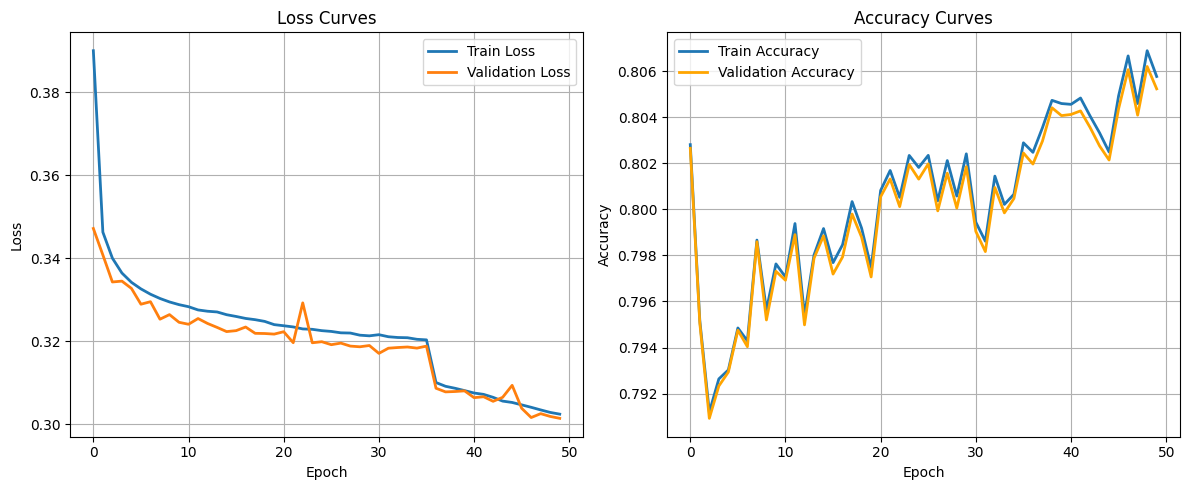

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 8: Plot Training Curves (đủ train/val loss và train/val accuracy)
# ──────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12,5))

# Subplot 1: Loss curves
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy curves
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

  116/10910 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step

I0000 00:00:1786390673.068231      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10910/10910 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step
===== Classification Report =====
              precision    recall  f1-score   support

           0       0.84      0.82      0.83    209448
           1       0.97      0.71      0.82    598978
           2       0.51      0.93      0.66    193688
           3       0.80      0.26      0.40      2504
           4       0.85      0.85      0.85     87173
           5       0.70      0.78      0.74    119826
           6       0.54      0.12      0.19      4741
           7       1.00      1.00      1.00    180000

    accuracy                           0.81   1396358
   macro avg       0.78      0.68      0.69   1396358
weighted avg       0.86      0.81      0.81   1396358



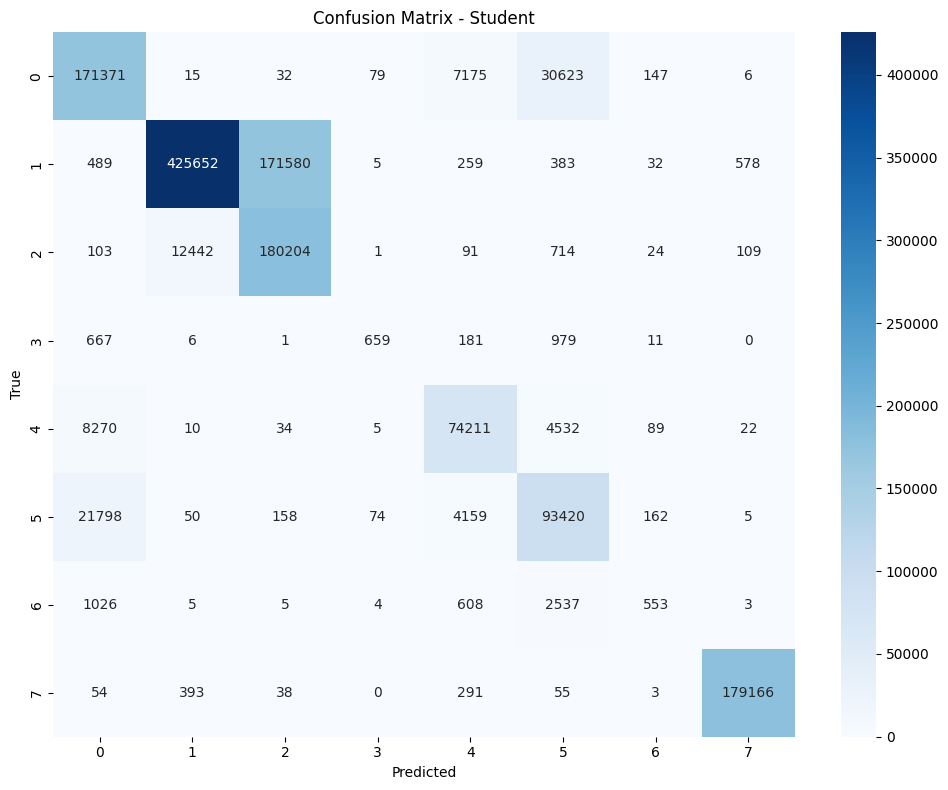

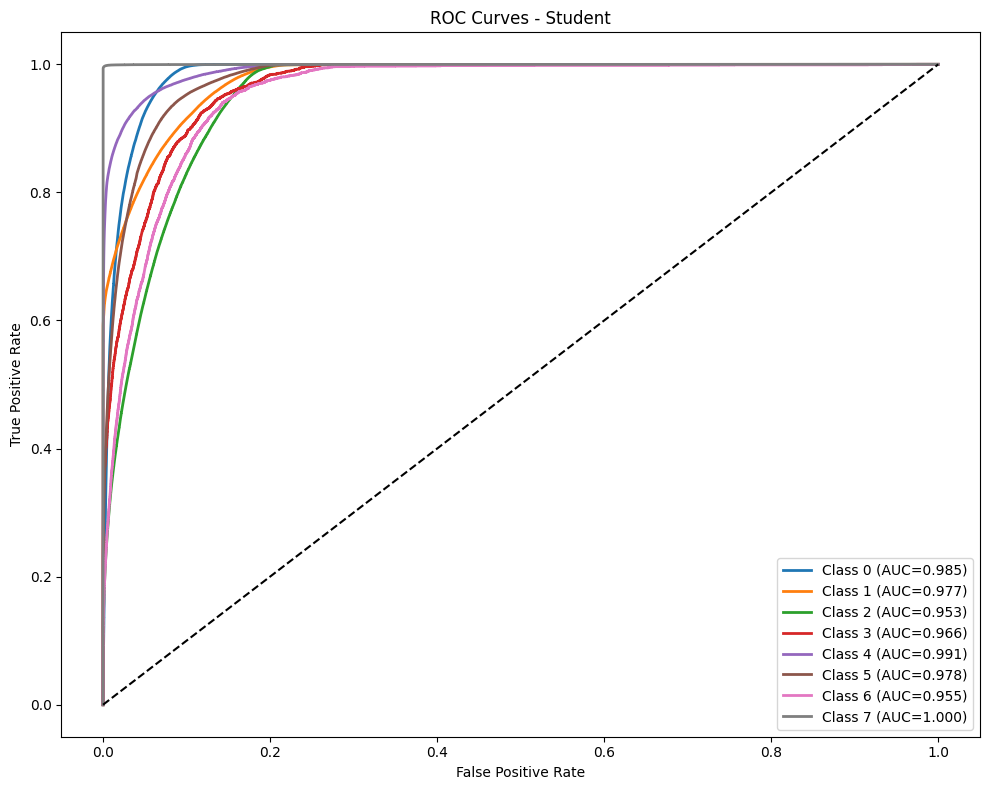

In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 9: Evaluation on Test Set
# ──────────────────────────────────────────────────────────────────────────────
test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_logits, axis=1)
test_probs = tf.nn.softmax(test_logits).numpy()

print("===== Classification Report =====")
print(classification_report(y_test, test_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Student')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# ROC Curves
y_bin = label_binarize(y_test, classes=range(num_classes))
plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Student')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves.png", dpi=150)
plt.show()

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 10: Heaviness Metrics (sửa lỗi FLOPs)
# ──────────────────────────────────────────────────────────────────────────────
# Model size
student.save("temp_student.keras")
size_mb = os.path.getsize("temp_student.keras") / (1024*1024)
os.remove("temp_student.keras")
print(f"Model size: {size_mb:.4f} MB")
print(f"Total parameters: {student.count_params()}")

# Approximate FLOPs (sửa lỗi)
def approx_flops(model):
    total = 0
    for layer in model.layers:
        if len(layer.weights) > 0:  # Dense layers có weights
            kernel = layer.weights[0]  # shape (input_dim, output_dim)
            input_dim = kernel.shape[0]
            output_dim = kernel.shape[1]
            total += input_dim * output_dim + output_dim  # phép nhân + bias
    return total

print(f"FLOPs per sample (approx): {approx_flops(student)}")

# Inference time
N = 2000
start = time.perf_counter()
student.predict(X_test[:N], batch_size=BATCH_SIZE, verbose=0)
inf_time = (time.perf_counter() - start) / N * 1000  # ms per sample
print(f"Inference time per sample: {inf_time:.4f} ms")

Model size: 0.0358 MB
Total parameters: 4776
FLOPs per sample (approx): 4776
Inference time per sample: 0.1695 ms


10910/10910 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step

CLASSIFICATION REPORT (digits=4)
              precision    recall  f1-score   support

           0     0.8410    0.8182    0.8294    209448
           1     0.9705    0.7106    0.8205    598978
           2     0.5119    0.9304    0.6604    193688
           3     0.7969    0.2632    0.3957      2504
           4     0.8532    0.8513    0.8523     87173
           5     0.7011    0.7796    0.7383    119826
           6     0.5416    0.1166    0.1919      4741
           7     0.9960    0.9954    0.9957    180000

    accuracy                         0.8058   1396358
   macro avg     0.7765    0.6832    0.6855   1396358
weighted avg     0.8586    0.8058    0.8142   1396358


----------------------------------------
Macro AUC   : 0.9757
Weighted AUC: 0.9788
Micro AUC   : 0.9878
----------------------------------------


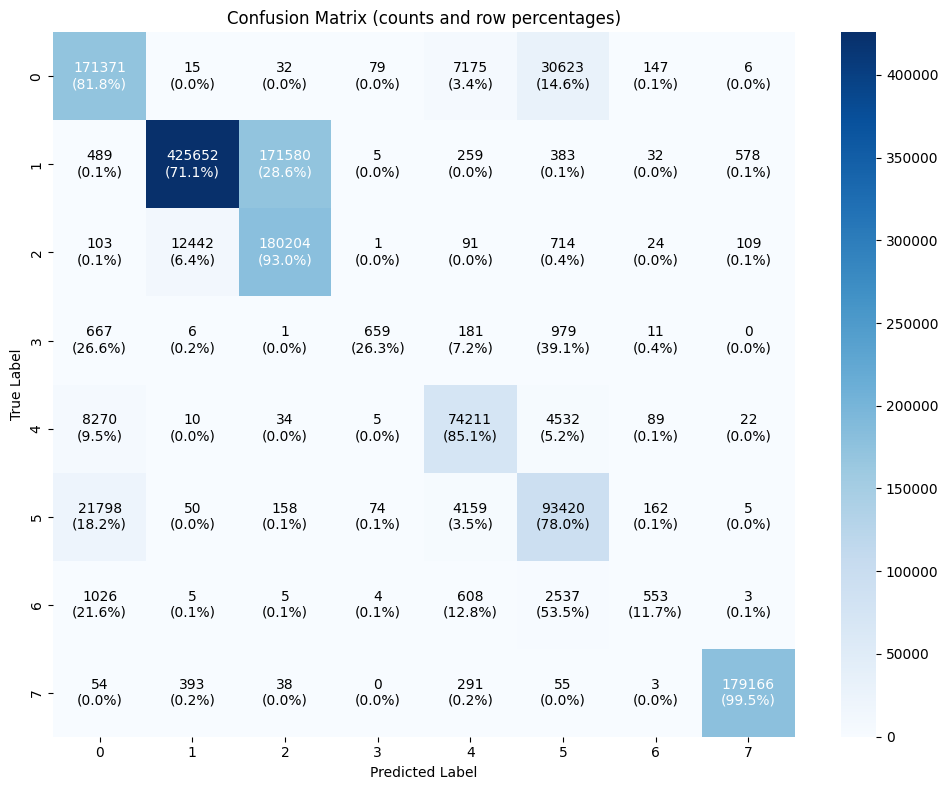

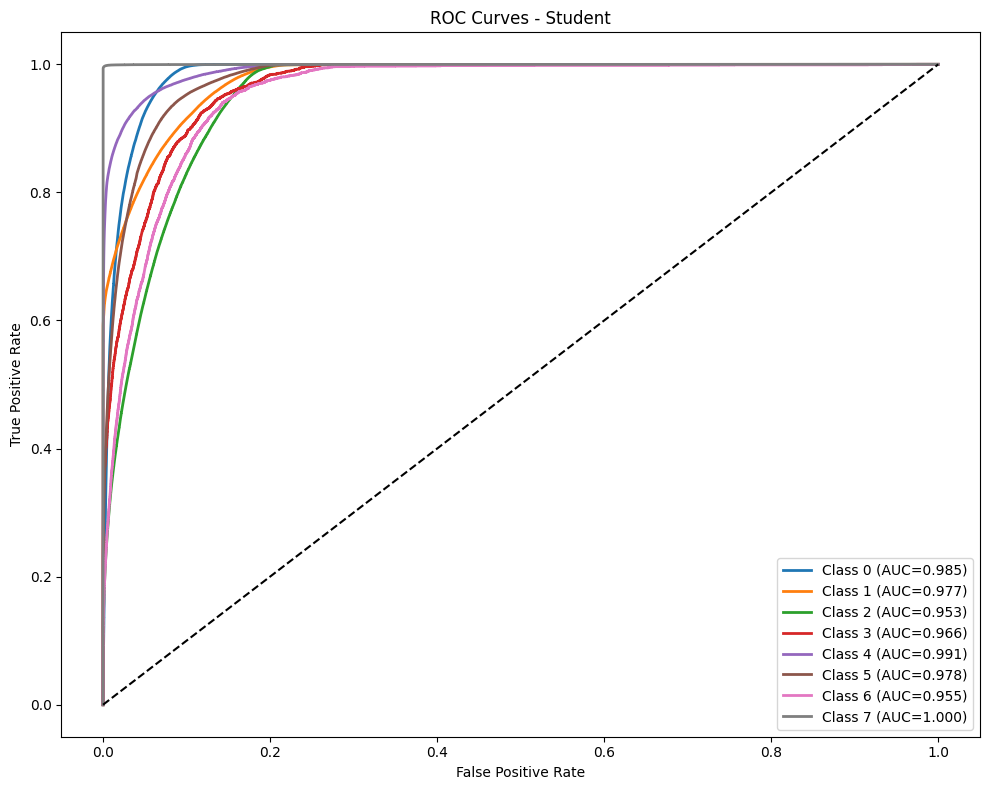

In [15]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL: Evaluation (có thể chạy độc lập hoặc sau khi train)
# ──────────────────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Cấu hình -----
# Đường dẫn đến model đã train (dùng khi chạy độc lập)
MODEL_PATH = "/kaggle/working/student_best.keras"      # File model tốt nhất từ training
METADATA_PATH = "/kaggle/working/metadata.json"
TEST_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
BATCH_SIZE = 128
OUTPUT_DIR = "/kaggle/working/"   # Thư mục output để lưu ảnh

# ----- 1. Load metadata -----
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)
num_classes = metadata['num_classes']
feature_cols = metadata['feature_cols']
target_col = metadata['target_col']

# ----- 2. Load model (nếu chưa có sẵn) -----
try:
    # Nếu biến 'student' đã tồn tại (từ training), dùng nó
    student
except NameError:
    print("Loading model from file...")
    student = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded.")

# ----- 3. Load dữ liệu test -----
df_test = pd.read_parquet(TEST_PATH)
X_test = df_test[feature_cols].values.astype(np.float32)
y_test = df_test[target_col].values.astype(np.int32)

# ----- 4. Dự đoán -----
test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_logits, axis=1)
test_probs = tf.nn.softmax(test_logits).numpy()

# ----- 5. Classification Report với 4 số thập phân -----
print("\n" + "="*60)
print("CLASSIFICATION REPORT (digits=4)")
print("="*60)
print(classification_report(y_test, test_preds, digits=4, zero_division=0))

# ----- 6. AUC (macro, weighted, micro) -----
y_bin = label_binarize(y_test, classes=range(num_classes))
auc_macro = roc_auc_score(y_bin, test_probs, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_bin, test_probs, average='weighted', multi_class='ovr')
auc_micro = roc_auc_score(y_bin, test_probs, average='micro', multi_class='ovr')
print("\n" + "-"*40)
print(f"Macro AUC   : {auc_macro:.4f}")
print(f"Weighted AUC: {auc_weighted:.4f}")
print(f"Micro AUC   : {auc_micro:.4f}")
print("-"*40)

# ----- 7. Confusion Matrix với count và % theo hàng -----
cm = confusion_matrix(y_test, test_preds)
# Tính phần trăm theo hàng (mỗi hàng = nhãn thực tế)
cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)

# Thêm annotation thủ công (count + percentage)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_percent[i, j]
        # Chọn màu chữ tương phản
        color = 'white' if count > cm.max() * 0.4 else 'black'
        plt.text(j + 0.5, i + 0.5, f"{count}\n({pct:.1f}%)",
                 ha='center', va='center', color=color, fontsize=10)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (counts and row percentages)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_with_pct.png", dpi=150)
plt.show()

# ----- 8. ROC curves (tùy chọn) -----
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={roc_auc_score(y_bin[:, i], test_probs[:, i]):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Student')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves.png", dpi=150)
plt.show()

In [16]:
# """
# PHƯƠNG ÁN 2 — TFLite float32 cho Raspberry Pi 4
# Giữ nguyên 100% hiệu năng model, runtime chỉ vài MB (không cần TensorFlow trên Pi).

#   PHẦN 1: chạy trên Kaggle  -> tạo file .tflite + kiểm chứng accuracy
#   PHẦN 2: chạy trên Pi 4    -> chỉ cần ai-edge-litert
# """

# # =============================================================================
# # PHẦN 1 — CHẠY TRÊN KAGGLE
# # =============================================================================
# import json
# import os

# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.metrics import accuracy_score, classification_report, f1_score

# MODEL_PATH = "/kaggle/input/models/binhthanh69/cw-lstm-model/keras/default/1/student_best.keras"
# METADATA_PATH = "/kaggle/working/metadata.json"
# TEST_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
# OUTPUT_DIR = "/kaggle/working/"
# TFLITE_PATH = os.path.join(OUTPUT_DIR, "student_fp32.tflite")

# with open(METADATA_PATH) as f:
#     meta = json.load(f)
# feature_cols, target_col = meta["feature_cols"], meta["target_col"]
# num_classes = meta["num_classes"]

# model = tf.keras.models.load_model(MODEL_PATH)

# # ------------------------------------------------------------------
# # 1.1 Chuyển đổi — KHÔNG bật optimizations, không representative_dataset
# # ------------------------------------------------------------------
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# # Cố ý để trống: mọi thứ giữ nguyên float32.
# tflite_model = converter.convert()

# with open(TFLITE_PATH, "wb") as f:
#     f.write(tflite_model)

# print(f"Đã lưu {TFLITE_PATH}")
# print(f"  Kích thước: {os.path.getsize(TFLITE_PATH) / 1024:.1f} KB")
# print(f"  Tham số   : {model.count_params()}")


# # ------------------------------------------------------------------
# # 1.2 Xuất tham số scaler cùng chỗ
# #     Bắt buộc: trên Pi bạn phải chuẩn hóa input y hệt lúc train.
# #     Nếu file parquet đã standardized sẵn, hãy lấy mean/scale từ
# #     đúng đối tượng StandardScaler đã dùng ở bước tiền xử lý.
# # ------------------------------------------------------------------
# SCALER_PATH = os.path.join(OUTPUT_DIR, "preprocessing.npz")
# try:
#     import joblib
#     scaler = joblib.load("")   # <-- sửa đường dẫn
#     np.savez(SCALER_PATH,
#              mean=scaler.mean_.astype(np.float32),
#              scale=scaler.scale_.astype(np.float32),
#              feature_cols=np.array(feature_cols))
#     print(f"Đã lưu {SCALER_PATH}")
# except Exception as e:
#     np.savez(SCALER_PATH, feature_cols=np.array(feature_cols))
#     print(f"\n⚠️  Chưa gắn được scaler ({type(e).__name__}).")
#     print("   Nhớ bổ sung mean/scale trước khi triển khai lên Pi,")
#     print("   nếu không input trên Pi sẽ sai thang đo và accuracy sẽ sụp.")


# # ------------------------------------------------------------------
# # 1.3 Kiểm chứng: TFLite float32 phải khớp Keras gần như tuyệt đối
# # ------------------------------------------------------------------
# df_test = pd.read_parquet(TEST_PATH)
# X_test = df_test[feature_cols].values.astype(np.float32)
# y_test = df_test[target_col].values.astype(np.int32)


# def run_tflite(path, X, batch=1024):
#     itp = tf.lite.Interpreter(model_path=path, num_threads=4)
#     inp, out = itp.get_input_details()[0], itp.get_output_details()[0]
#     itp.resize_tensor_input(inp["index"], [batch, X.shape[1]])
#     itp.allocate_tensors()

#     logits = np.empty((len(X), num_classes), dtype=np.float32)
#     for i in range(0, len(X), batch):
#         xb = X[i:i + batch]
#         if xb.shape[0] != batch:
#             itp.resize_tensor_input(inp["index"], list(xb.shape))
#             itp.allocate_tensors()
#         itp.set_tensor(inp["index"], xb)
#         itp.invoke()
#         logits[i:i + len(xb)] = itp.get_tensor(out["index"])
#     return logits


# logits_keras = model.predict(X_test, batch_size=1024, verbose=0)
# logits_tflite = run_tflite(TFLITE_PATH, X_test)

# pred_k = logits_keras.argmax(1)
# pred_t = logits_tflite.argmax(1)

# print("\n" + "=" * 70)
# print("KIỂM CHỨNG TFLITE FLOAT32")
# print(f"  Sai lệch tối đa trên logits : {np.abs(logits_keras - logits_tflite).max():.8f}")
# print(f"  Tỉ lệ khớp argmax           : {(pred_k == pred_t).mean():.6f}")
# print(f"  Accuracy Keras              : {accuracy_score(y_test, pred_k):.4f}")
# print(f"  Accuracy TFLite             : {accuracy_score(y_test, pred_t):.4f}")
# print(f"  Macro F1 Keras              : {f1_score(y_test, pred_k, average='macro'):.4f}")
# print(f"  Macro F1 TFLite             : {f1_score(y_test, pred_t, average='macro'):.4f}")
# print("=" * 70)
# print("  Sai lệch nên ở mức 1e-5 hoặc nhỏ hơn. Nếu lớn hơn nhiều -> báo lại.")

# print("\n" + classification_report(y_test, pred_t, digits=4, zero_division=0))


In [17]:
# """
# KHẢO SÁT SO SÁNH CÁC PHƯƠNG ÁN LƯỢNG TỬ HÓA
# Student MLP 37 -> 64 -> 32 -> 8, triển khai trên Raspberry Pi 4

# Ba biến thể:
#   A. fp32          - float32 thuần, mốc chuẩn
#   B. dynamic       - weights int8, activation float32
#   C. full_int8     - toàn bộ int8, cần representative dataset

# Đầu ra: bảng so sánh dung lượng / chất lượng / tốc độ + file CSV.

#   PHẦN 1-4: chạy trên Kaggle
#   PHẦN 5  : sinh script benchmark riêng để chạy trên Pi
# """

# import json
# import os
# import time

# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
# from sklearn.preprocessing import label_binarize

# # =============================================================================
# # PHẦN 1 — Cấu hình & dữ liệu
# # =============================================================================
# MODEL_PATH = "/kaggle/input/models/binhthanh69/cw-lstm-model/keras/default/1/student_best.keras"
# METADATA_PATH = "/kaggle/working/metadata.json"
# TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
# TEST_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
# OUTPUT_DIR = "/kaggle/working/"

# N_CALIB_PER_CLASS = 500
# EVAL_BATCH = 1024
# RNG = np.random.default_rng(42)

# with open(METADATA_PATH) as f:
#     meta = json.load(f)
# feature_cols, target_col = meta["feature_cols"], meta["target_col"]
# num_classes = meta["num_classes"]

# model = tf.keras.models.load_model(MODEL_PATH)

# df_train = pd.read_parquet(TRAIN_PATH)
# X_train = df_train[feature_cols].values.astype(np.float32)
# y_train = df_train[target_col].values.astype(np.int32)
# del df_train

# df_test = pd.read_parquet(TEST_PATH)
# X_test = df_test[feature_cols].values.astype(np.float32)
# y_test = df_test[target_col].values.astype(np.int32)
# del df_test

# print(f"Test: {X_test.shape}, classes: {num_classes}")


# # =============================================================================
# # PHẦN 2 — Chuyển đổi ba biến thể
# # =============================================================================
# calib_idx = np.concatenate([
#     RNG.choice(np.where(y_train == c)[0],
#                min(N_CALIB_PER_CLASS, int((y_train == c).sum())), replace=False)
#     for c in range(num_classes) if (y_train == c).sum() > 0
# ])
# RNG.shuffle(calib_idx)
# X_calib = X_train[calib_idx]
# print(f"Calibration: {X_calib.shape} (phân tầng theo class)")


# def representative_dataset():
#     for i in range(0, len(X_calib), 32):
#         yield [X_calib[i:i + 32]]


# def convert(variant, path):
#     c = tf.lite.TFLiteConverter.from_keras_model(model)

#     if variant == "fp32":
#         pass                                              # không tối ưu gì
#     elif variant == "dynamic":
#         c.optimizations = [tf.lite.Optimize.DEFAULT]      # weights int8
#     elif variant == "full_int8":
#         c.optimizations = [tf.lite.Optimize.DEFAULT]
#         c.representative_dataset = representative_dataset
#         c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
#         c.inference_input_type = tf.float32               # để TFLite tự quantize
#         c.inference_output_type = tf.float32
#     else:
#         raise ValueError(variant)

#     blob = c.convert()
#     with open(path, "wb") as f:
#         f.write(blob)
#     return path


# VARIANTS = {
#     "A. fp32": "fp32",
#     "B. dynamic int8": "dynamic",
#     "C. full int8": "full_int8",
# }

# paths = {}
# for label, v in VARIANTS.items():
#     p = os.path.join(OUTPUT_DIR, f"student_{v}.tflite")
#     convert(v, p)
#     paths[label] = p
#     print(f"{label:<18} -> {os.path.getsize(p) / 1024:6.1f} KB")


# # =============================================================================
# # PHẦN 3 — Đánh giá chất lượng
# # =============================================================================
# def run_tflite(path, X, batch=EVAL_BATCH, threads=4):
#     itp = tf.lite.Interpreter(model_path=path, num_threads=threads)
#     inp, out = itp.get_input_details()[0], itp.get_output_details()[0]
#     itp.resize_tensor_input(inp["index"], [batch, X.shape[1]])
#     itp.allocate_tensors()

#     logits = np.empty((len(X), num_classes), dtype=np.float32)
#     for i in range(0, len(X), batch):
#         xb = X[i:i + batch]
#         if xb.shape[0] != batch:
#             itp.resize_tensor_input(inp["index"], list(xb.shape))
#             itp.allocate_tensors()
#         itp.set_tensor(inp["index"], np.ascontiguousarray(xb, np.float32))
#         itp.invoke()
#         logits[i:i + len(xb)] = itp.get_tensor(out["index"])
#     return logits


# def softmax(z):
#     z = z - z.max(axis=1, keepdims=True)
#     e = np.exp(z)
#     return e / e.sum(axis=1, keepdims=True)


# # Mốc chuẩn: Keras gốc
# logits_ref = model.predict(X_test, batch_size=EVAL_BATCH, verbose=0)
# pred_ref = logits_ref.argmax(1)
# y_bin = label_binarize(y_test, classes=range(num_classes))

# rows = [{
#     "Biến thể": "Keras (.keras)",
#     "Dung lượng (KB)": os.path.getsize(MODEL_PATH) / 1024,
#     "Accuracy": accuracy_score(y_test, pred_ref),
#     "Macro F1": f1_score(y_test, pred_ref, average="macro", zero_division=0),
#     "Weighted F1": f1_score(y_test, pred_ref, average="weighted", zero_division=0),
#     "Macro AUC": roc_auc_score(y_bin, softmax(logits_ref), average="macro", multi_class="ovr"),
#     "Khớp argmax": 1.0,
#     "MAE logits": 0.0,
# }]

# per_class_f1 = {"Keras": f1_score(y_test, pred_ref, average=None, zero_division=0)}
# all_logits = {}

# for label, path in paths.items():
#     lg = run_tflite(path, X_test)
#     all_logits[label] = lg
#     pred = lg.argmax(1)
#     rows.append({
#         "Biến thể": label,
#         "Dung lượng (KB)": os.path.getsize(path) / 1024,
#         "Accuracy": accuracy_score(y_test, pred),
#         "Macro F1": f1_score(y_test, pred, average="macro", zero_division=0),
#         "Weighted F1": f1_score(y_test, pred, average="weighted", zero_division=0),
#         "Macro AUC": roc_auc_score(y_bin, softmax(lg), average="macro", multi_class="ovr"),
#         "Khớp argmax": (pred == pred_ref).mean(),
#         "MAE logits": np.abs(lg - logits_ref).mean(),
#     })
#     per_class_f1[label] = f1_score(y_test, pred, average=None, zero_division=0)

# df_quality = pd.DataFrame(rows)


# # =============================================================================
# # PHẦN 4 — Đo tốc độ (trên CPU Kaggle; Pi 4 sẽ chậm hơn, xem PHẦN 5)
# # =============================================================================
# def bench(path, n_feat, batch, threads, n_rep=200):
#     itp = tf.lite.Interpreter(model_path=path, num_threads=threads)
#     inp = itp.get_input_details()[0]
#     itp.resize_tensor_input(inp["index"], [batch, n_feat])
#     itp.allocate_tensors()
#     x = np.random.randn(batch, n_feat).astype(np.float32)

#     for _ in range(20):                                   # warm-up
#         itp.set_tensor(inp["index"], x)
#         itp.invoke()

#     t0 = time.perf_counter()
#     for _ in range(n_rep):
#         itp.set_tensor(inp["index"], x)
#         itp.invoke()
#     return (time.perf_counter() - t0) / n_rep / batch * 1e6   # µs / mẫu


# speed_rows = []
# for label, path in paths.items():
#     row = {"Biến thể": label}
#     for batch in (1, 32, 128):
#         for threads in (1, 4):
#             row[f"b{batch}/t{threads} (µs)"] = bench(path, X_test.shape[1], batch, threads)
#     speed_rows.append(row)

# df_speed = pd.DataFrame(speed_rows)


# # ---------------------------- In kết quả ----------------------------
# pd.set_option("display.width", 200, "display.max_columns", 50)

# print("\n" + "=" * 100)
# print("BẢNG 1 — CHẤT LƯỢNG")
# print("=" * 100)
# print(df_quality.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# print("\n" + "=" * 100)
# print("BẢNG 2 — TỐC ĐỘ (µs/mẫu, CPU Kaggle x86 — chỉ để tham khảo tương đối)")
# print("=" * 100)
# print(df_speed.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

# print("\n" + "=" * 100)
# print("BẢNG 3 — F1 THEO TỪNG CLASS")
# print("=" * 100)
# print(pd.DataFrame(per_class_f1, index=[f"class {i}" for i in range(num_classes)])
#       .to_string(float_format=lambda v: f"{v:.4f}"))

# df_quality.to_csv(os.path.join(OUTPUT_DIR, "khaosat_chatluong.csv"), index=False)
# df_speed.to_csv(os.path.join(OUTPUT_DIR, "khaosat_tocdo.csv"), index=False)
# pd.DataFrame(per_class_f1).to_csv(os.path.join(OUTPUT_DIR, "khaosat_f1_class.csv"), index=False)
# print("\nĐã lưu 3 file CSV vào", OUTPUT_DIR)

